In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [110]:
path = '/home/eduarda/jupyter_ic/data/raw/FINFET/7nm/NOT/sim1/all_results_inverter.csv'

data = pd.read_csv(path, index_col=0)

data

,1,2,LoadCap,vdd,number_fin,index,temp,montecarlo_iteration,tphl,tplh,total_power,iint,temper,alter#
0,4.370067,4.852864,1f,0.6,1,1,-25,1,1.230100e-11,1.582600e-11,-9.601460e-09,-6.400970e-16,-25,1
1,4.370806,4.873612,1f,0.6,1,2,-25,2,1.232850e-11,1.470250e-11,-9.648810e-09,-6.432540e-16,-25,1
2,4.333499,4.850897,1f,0.6,1,3,-25,3,1.128970e-11,1.594150e-11,-9.603980e-09,-6.402650e-16,-25,1
3,4.407237,4.856645,1f,0.6,1,4,-25,4,1.353270e-11,1.560170e-11,-9.595290e-09,-6.396860e-16,-25,1
4,4.387795,4.770993,1f,0.6,1,5,-25,5,1.282430e-11,2.289280e-11,-9.530360e-09,-6.353580e-16,-25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16f,0.9,5,596,100,96,3.889300e-11,3.870920e-11,-4.524430e-07,-2.010860e-14,100,1
47996,4.379719,4.855940,16f,0.9,5,597,100,97,4.406050e-11,3.445420e-11,-1.128870e-06,-5.017210e-14,100,1
47997,4.435190,4.791605,16f,0.9,5,598,100,98,5.173240e-11,3.773370e-11,-5.086850e-07,-2.260820e-14,100,1
47998,4.323838,4.781360,16f,0.9,5,599,100,99,3.772690e-11,3.840220e-11,-4.723270e-07,-2.099230e-14,100,1


In [111]:
data = data.rename(columns={
    '1': 'nfetPhig', 
    '2': 'pfetPhig', 
    'alter#': 'alter', 
    'vdd': 'voltage', 
    'LoadCap': 'capacitance',
    'number_fin': 'finsNumber',
    'montecarlo_iteration': 'monteCarloIteration',
    'total_power': 'totalPower',
})

data

,nfetPhig,pfetPhig,capacitance,voltage,finsNumber,index,temp,monteCarloIteration,tphl,tplh,totalPower,iint,temper,alter
0,4.370067,4.852864,1f,0.6,1,1,-25,1,1.230100e-11,1.582600e-11,-9.601460e-09,-6.400970e-16,-25,1
1,4.370806,4.873612,1f,0.6,1,2,-25,2,1.232850e-11,1.470250e-11,-9.648810e-09,-6.432540e-16,-25,1
2,4.333499,4.850897,1f,0.6,1,3,-25,3,1.128970e-11,1.594150e-11,-9.603980e-09,-6.402650e-16,-25,1
3,4.407237,4.856645,1f,0.6,1,4,-25,4,1.353270e-11,1.560170e-11,-9.595290e-09,-6.396860e-16,-25,1
4,4.387795,4.770993,1f,0.6,1,5,-25,5,1.282430e-11,2.289280e-11,-9.530360e-09,-6.353580e-16,-25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16f,0.9,5,596,100,96,3.889300e-11,3.870920e-11,-4.524430e-07,-2.010860e-14,100,1
47996,4.379719,4.855940,16f,0.9,5,597,100,97,4.406050e-11,3.445420e-11,-1.128870e-06,-5.017210e-14,100,1
47997,4.435190,4.791605,16f,0.9,5,598,100,98,5.173240e-11,3.773370e-11,-5.086850e-07,-2.260820e-14,100,1
47998,4.323838,4.781360,16f,0.9,5,599,100,99,3.772690e-11,3.840220e-11,-4.723270e-07,-2.099230e-14,100,1


In [112]:
for col in data:
    print(col)

nfetPhig
pfetPhig
capacitance
voltage
finsNumber
index
temp
monteCarloIteration
tphl
tplh
totalPower
iint
temper
alter


Variables
- **nfetPhig**:
- **pfetPhig**:
- **capacitance**:
- **voltage**: tensão de alimentação (vdd)
- **finsNumber**:
- **index**
- **temp**:	temperatura de operação do circuito
- **monteCarloIteration**
- **tphl**:	tempo de propagação da saída High -> Low
- **tplh**: tempo de propagação da saída Low -> High
- **totalPower**
- **iint**:	energia dissipada pelo circuito
- **temper**:	temperatura de operação do circuito
- **alter**

- **finLength** (fixed 2.1e-8):
- **finHeight** (fixed 3.2e-8):

In [113]:
#data = data.drop("alter", axis=1)
#data = data.drop("index", axis=1)
#data = data.drop("nfetPhig", axis=1)
#data = data.drop("pfetPhig", axis=1)
#data = data.drop("capacitance", axis=1)
#data = data.drop("totalPower", axis=1)
#data = data.drop("monteCarloIteration", axis=1)
#data = data.drop("temp", axis=1)

data["finLength"] = 2.1e-8
data["finHeight"] = 3.2e-8


data

,nfetPhig,pfetPhig,capacitance,voltage,finsNumber,index,temp,monteCarloIteration,tphl,tplh,totalPower,iint,temper,alter,finLength,finHeight
0,4.370067,4.852864,1f,0.6,1,1,-25,1,1.230100e-11,1.582600e-11,-9.601460e-09,-6.400970e-16,-25,1,2.100000e-08,3.200000e-08
1,4.370806,4.873612,1f,0.6,1,2,-25,2,1.232850e-11,1.470250e-11,-9.648810e-09,-6.432540e-16,-25,1,2.100000e-08,3.200000e-08
2,4.333499,4.850897,1f,0.6,1,3,-25,3,1.128970e-11,1.594150e-11,-9.603980e-09,-6.402650e-16,-25,1,2.100000e-08,3.200000e-08
3,4.407237,4.856645,1f,0.6,1,4,-25,4,1.353270e-11,1.560170e-11,-9.595290e-09,-6.396860e-16,-25,1,2.100000e-08,3.200000e-08
4,4.387795,4.770993,1f,0.6,1,5,-25,5,1.282430e-11,2.289280e-11,-9.530360e-09,-6.353580e-16,-25,1,2.100000e-08,3.200000e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,4.336670,4.776053,16f,0.9,5,596,100,96,3.889300e-11,3.870920e-11,-4.524430e-07,-2.010860e-14,100,1,2.100000e-08,3.200000e-08
47996,4.379719,4.855940,16f,0.9,5,597,100,97,4.406050e-11,3.445420e-11,-1.128870e-06,-5.017210e-14,100,1,2.100000e-08,3.200000e-08
47997,4.435190,4.791605,16f,0.9,5,598,100,98,5.173240e-11,3.773370e-11,-5.086850e-07,-2.260820e-14,100,1,2.100000e-08,3.200000e-08
47998,4.323838,4.781360,16f,0.9,5,599,100,99,3.772690e-11,3.840220e-11,-4.723270e-07,-2.099230e-14,100,1,2.100000e-08,3.200000e-08


In [114]:
for col in data:
    print(col)

nfetPhig
pfetPhig
capacitance
voltage
finsNumber
index
temp
monteCarloIteration
tphl
tplh
totalPower
iint
temper
alter
finLength
finHeight


Variables
- **tphl**:	tempo de propagação da saída High -> Low
- **tplh**: tempo de propagação da saída Low -> High
- **iint**:	energia dissipada pelo circuito
- **temper**:	temperatura de operação do circuito
- **voltage**: tensão de alimentação (vdd)
- **finsNumber**:
- **finLength**:
- **finHeight**:

In [115]:
inp_var = ["voltage", "finsNumber", "temper", "finLength", "finHeight"]
unique = {}
for col in inp_var:
  unique[col] = list(np.sort(data[col].unique()))
unique

{'voltage': [np.float64(0.6),
  np.float64(0.7),
  np.float64(0.8),
  np.float64(0.9)],
 'finsNumber': [np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5)],
 'temper': [np.int64(-25),
  np.int64(0),
  np.int64(25),
  np.int64(50),
  np.int64(75),
  np.int64(100)],
 'finLength': [np.float64(2.1e-08)],
 'finHeight': [np.float64(3.2e-08)]}

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48000 entries, 0 to 47999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nfetPhig             48000 non-null  float64
 1   pfetPhig             48000 non-null  float64
 2   capacitance          48000 non-null  object 
 3   voltage              48000 non-null  float64
 4   finsNumber           48000 non-null  int64  
 5   index                48000 non-null  int64  
 6   temp                 48000 non-null  int64  
 7   monteCarloIteration  48000 non-null  int64  
 8   tphl                 48000 non-null  float64
 9   tplh                 48000 non-null  float64
 10  totalPower           48000 non-null  float64
 11  iint                 48000 non-null  float64
 12  temper               48000 non-null  int64  
 13  alter                48000 non-null  int64  
 14  finLength            48000 non-null  float64
 15  finHeight            48000 non-null  floa

In [117]:
data.describe()

,nfetPhig,pfetPhig,voltage,finsNumber,index,temp,monteCarloIteration,tphl,tplh,totalPower,iint,temper,alter,finLength,finHeight
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,4.800000e+04,4.800000e+04,4.800000e+04,4.800000e+04,48000.000000,48000.0,4.800000e+04,4.800000e+04
mean,4.371422,4.817980,0.750000,3.000000,300.500000,37.500000,50.500000,3.825212e-11,4.361243e-11,-1.501255e-07,-7.516414e-15,37.500000,1.0,2.100000e-08,3.200000e-08
std,0.041990,0.049145,0.111805,1.414228,173.206644,42.696073,28.866371,4.058639e-11,4.780905e-11,2.024699e-07,9.001894e-15,42.696073,0.0,9.926271e-24,6.617514e-24
min,4.281295,4.706879,0.600000,1.000000,1.000000,-25.000000,1.000000,3.254290e-12,3.220530e-12,-3.724030e-06,-1.655130e-13,-25.000000,1.0,2.100000e-08,3.200000e-08
25%,4.338745,4.785972,0.675000,2.000000,150.750000,0.000000,25.750000,1.191665e-11,1.296255e-11,-1.975570e-07,-1.014803e-14,0.000000,1.0,2.100000e-08,3.200000e-08
50%,4.371549,4.818547,0.750000,3.000000,300.500000,37.500000,50.500000,2.411275e-11,2.724980e-11,-9.954455e-08,-5.400255e-15,37.500000,1.0,2.100000e-08,3.200000e-08
75%,4.399487,4.852915,0.825000,4.000000,450.250000,75.000000,75.250000,4.770710e-11,5.387638e-11,-3.883568e-08,-2.555705e-15,75.000000,1.0,2.100000e-08,3.200000e-08
max,4.496100,4.944579,0.900000,5.000000,600.000000,100.000000,100.000000,3.125850e-10,4.771520e-10,-8.705990e-09,-5.803990e-16,100.000000,1.0,2.100000e-08,3.200000e-08


In [118]:
data.shape

(48000, 16)

In [119]:
data.nunique()

nfetPhig                 100
pfetPhig                 100
capacitance                4
voltage                    4
finsNumber                 5
index                    600
temp                       6
monteCarloIteration      100
tphl                   35369
tplh                   35463
totalPower             43300
iint                   44144
temper                     6
alter                      1
finLength                  1
finHeight                  1
dtype: int64

In [120]:
data.isnull().sum()

nfetPhig               0
pfetPhig               0
capacitance            0
voltage                0
finsNumber             0
index                  0
temp                   0
monteCarloIteration    0
tphl                   0
tplh                   0
totalPower             0
iint                   0
temper                 0
alter                  0
finLength              0
finHeight              0
dtype: int64

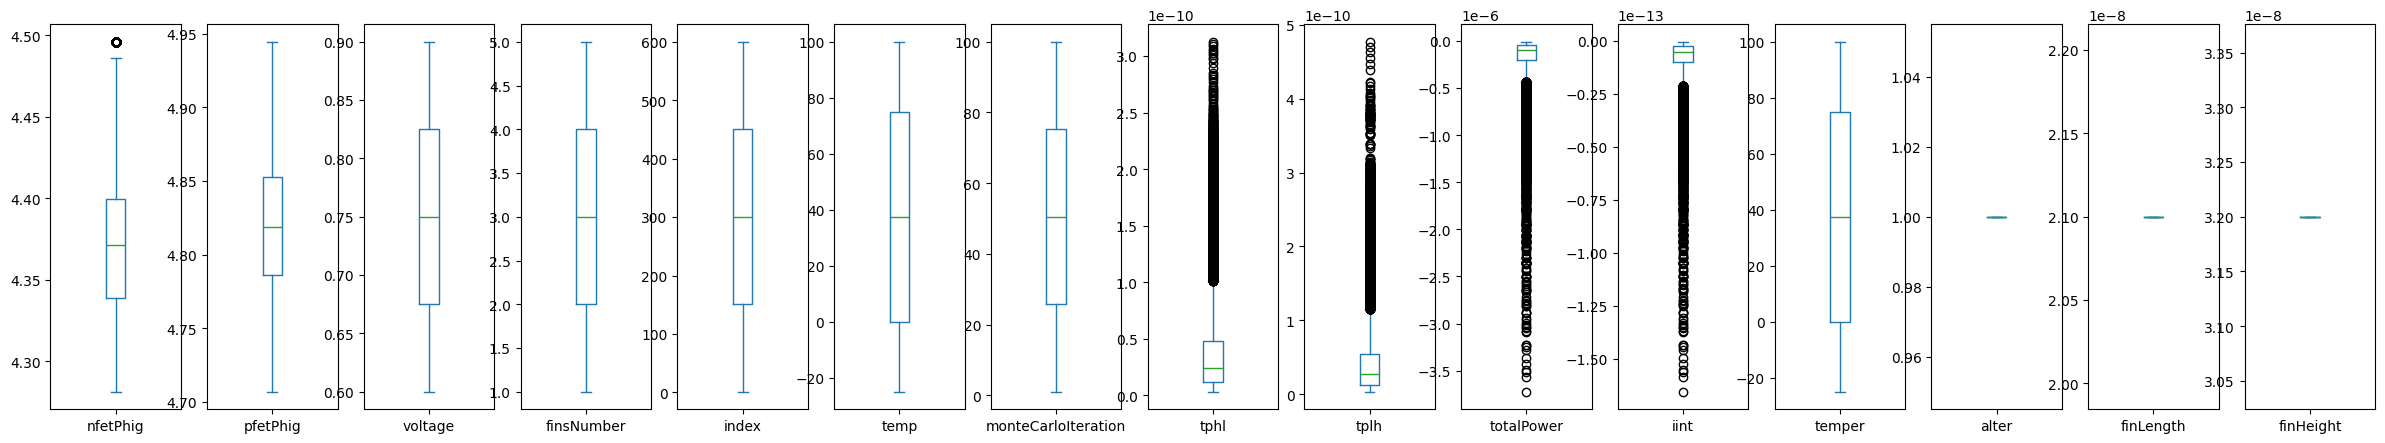

<Figure size 640x480 with 0 Axes>

In [121]:
data.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

In [122]:
# Outliers
from scipy.stats import zscore
out_var = ["tphl", "tplh", "iint"]
filtered_list = []
for case in data.index.unique(level="case"):
    tmp = data.loc[slice(case, case), :]
    not_outlier = (np.abs(zscore(tmp[out_var])) < 3).all(axis=1)
    filtered_list.append(tmp[not_outlier])
filtered = pd.concat(filtered_list)
filtered

KeyError: 'Requested level (case) does not match index name (None)'